In [11]:
%matplotlib qt5
#%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({
    'font.size': 14, 'grid.alpha': 0.5, 'grid.linestyle': '--',
    'axes.grid': True,
})

# comment

In [12]:
# terminal command to update repositories (pymodels, pyaccel, ...):

# pip install -e . --config-settings editable_mode=strict

# Pymodels

Python module for accelerator modelling

### Accelerator Models

- Linac: li
- Transport Line - Linac to Booster: tb
- Booster: bo
- Transport Line - Booster to Sirius: ts
- Sirius (Storage Ring): si

In [13]:
import pymodels
import pyaccel as pa

In [14]:
model = pymodels.si.create_accelerator()
# model = pa.lattice.refine_lattice(model)
model.cavity_on = False
model.radiation_on = False
model.vchamber_on = False

In [15]:
print(model)

energy         : 3000000000.0 eV
harmonic_number: 864
cavity_on      : False
radiation_on   : 0
vchamber_on    : False
lattice version: SI_V25_04_1.21.3
lattice size   : 6752
lattice length : 518.3898999999917 m


**Family** = A set of objects of exactly same type. 

Examples:
- Central Dipoles (BC)
- Focusing quadrupoles in high beta segments (QFA)
- Beam Position Monitors (BPM)

Getting data about families:

In [16]:
# fam_name with devname, index, subsection
famdata = pymodels.si.get_family_data(model)

In [17]:
# famdata is a nested dict (dict of dicts) with lists in each value:

nested_dict = {
    'B1': {'index': [[1, 5], [35, 39]], 'subsection': ['01C1', '01C4'], 'instance': ["", ""], 'devnames': ['SI-01...', 'SI-...']},
    'B2': {'index': [[2, 4], [36, 38]], 'subsection': ['01C1', '01C4'], 'instance': ["", ""], 'devnames': ['SI-01...', 'SI-...']}
               }

print('famdata:', nested_dict,
      '\nindex (B1):', nested_dict['B1']['index'],
      '\nsubsection (B1):', nested_dict['B1']['subsection'])


famdata: {'B1': {'index': [[1, 5], [35, 39]], 'subsection': ['01C1', '01C4'], 'instance': ['', ''], 'devnames': ['SI-01...', 'SI-...']}, 'B2': {'index': [[2, 4], [36, 38]], 'subsection': ['01C1', '01C4'], 'instance': ['', ''], 'devnames': ['SI-01...', 'SI-...']}} 
index (B1): [[1, 5], [35, 39]] 
subsection (B1): ['01C1', '01C4']


In [18]:
famdata['BC']['subsection']

['01BC',
 '02BC',
 '03BC',
 '04BC',
 '05BC',
 '06BC',
 '07BC',
 '08BC',
 '09BC',
 '10BC',
 '11BC',
 '12BC',
 '13BC',
 '14BC',
 '15BC',
 '16BC',
 '17BC',
 '18BC',
 '19BC',
 '20BC']

In [19]:
bcidx = famdata['BC']['index']

In [20]:
print(bcidx)
print(bcidx[19])

[[152, 153, 154, 156, 157, 158, 160, 161, 163, 164, 165, 166, 167, 168, 169, 170, 171, 174, 175, 176, 177, 178, 179, 180, 181, 182, 184, 185, 187, 188, 189, 191, 192, 193], [489, 490, 491, 493, 494, 495, 497, 498, 500, 501, 502, 503, 504, 505, 506, 507, 508, 511, 512, 513, 514, 515, 516, 517, 518, 519, 521, 522, 524, 525, 526, 528, 529, 530], [824, 825, 826, 828, 829, 830, 832, 833, 835, 836, 837, 838, 839, 840, 841, 842, 843, 846, 847, 848, 849, 850, 851, 852, 853, 854, 856, 857, 859, 860, 861, 863, 864, 865], [1160, 1161, 1162, 1164, 1165, 1166, 1168, 1169, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1179, 1182, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1192, 1193, 1195, 1196, 1197, 1199, 1200, 1201], [1492, 1493, 1494, 1496, 1497, 1498, 1500, 1501, 1503, 1504, 1505, 1506, 1507, 1508, 1509, 1510, 1511, 1514, 1515, 1516, 1517, 1518, 1519, 1520, 1521, 1522, 1524, 1525, 1527, 1528, 1529, 1531, 1532, 1533], [1830, 1831, 1832, 1834, 1835, 1836, 1838, 1839, 1841, 1842, 1843, 1844

In [21]:
print(np.shape(famdata['BC']['index']))
print(np.shape(famdata['B1']['index']))
print(np.shape(famdata['B2']['index']))

(20, 34)
(40, 32)
(40, 38)


Some families have devnames keys:

In [12]:
np.shape(famdata['BPM']['index'])

(160, 1)

In [13]:
famdata['BPM']['devnames']

['SI-01M2:DI-BPM',
 'SI-01C1:DI-BPM-1',
 'SI-01C1:DI-BPM-2',
 'SI-01C2:DI-BPM',
 'SI-01C3:DI-BPM-1',
 'SI-01C3:DI-BPM-2',
 'SI-01C4:DI-BPM',
 'SI-02M1:DI-BPM',
 'SI-02M2:DI-BPM',
 'SI-02C1:DI-BPM-1',
 'SI-02C1:DI-BPM-2',
 'SI-02C2:DI-BPM',
 'SI-02C3:DI-BPM-1',
 'SI-02C3:DI-BPM-2',
 'SI-02C4:DI-BPM',
 'SI-03M1:DI-BPM',
 'SI-03M2:DI-BPM',
 'SI-03C1:DI-BPM-1',
 'SI-03C1:DI-BPM-2',
 'SI-03C2:DI-BPM',
 'SI-03C3:DI-BPM-1',
 'SI-03C3:DI-BPM-2',
 'SI-03C4:DI-BPM',
 'SI-04M1:DI-BPM',
 'SI-04M2:DI-BPM',
 'SI-04C1:DI-BPM-1',
 'SI-04C1:DI-BPM-2',
 'SI-04C2:DI-BPM',
 'SI-04C3:DI-BPM-1',
 'SI-04C3:DI-BPM-2',
 'SI-04C4:DI-BPM',
 'SI-05M1:DI-BPM',
 'SI-05M2:DI-BPM',
 'SI-05C1:DI-BPM-1',
 'SI-05C1:DI-BPM-2',
 'SI-05C2:DI-BPM',
 'SI-05C3:DI-BPM-1',
 'SI-05C3:DI-BPM-2',
 'SI-05C4:DI-BPM',
 'SI-06M1:DI-BPM',
 'SI-06M2:DI-BPM',
 'SI-06C1:DI-BPM-1',
 'SI-06C1:DI-BPM-2',
 'SI-06C2:DI-BPM',
 'SI-06C3:DI-BPM-1',
 'SI-06C3:DI-BPM-2',
 'SI-06C4:DI-BPM',
 'SI-07M1:DI-BPM',
 'SI-07M2:DI-BPM',
 'SI-07C1:DI-BPM-1',


Finding out the families names

In [14]:
pymodels.si.families.families_pulsed_magnets()

['InjDpKckr', 'InjNLKckr', 'PingH', 'PingV']

In [15]:
pymodels.si.families.families_dipoles()

['B1', 'B2', 'BC']

In [16]:
pymodels.si.families.families_quadrupoles()

['QFA',
 'QDA',
 'QFB',
 'QDB1',
 'QDB2',
 'QFP',
 'QDP1',
 'QDP2',
 'Q1',
 'Q2',
 'Q3',
 'Q4']

In [17]:
famdata['QFA']['index']

[[18], [1334], [1358], [2680], [2702], [4028], [4052], [5380], [5404], [6729]]

In [18]:
pymodels.si.families.families_sextupoles()

['SDA0',
 'SDB0',
 'SDP0',
 'SDA1',
 'SDB1',
 'SDP1',
 'SDA2',
 'SDB2',
 'SDP2',
 'SDA3',
 'SDB3',
 'SDP3',
 'SFA0',
 'SFB0',
 'SFP0',
 'SFA1',
 'SFB1',
 'SFP1',
 'SFA2',
 'SFB2',
 'SFP2']

In [19]:
# Diagnostic families
pymodels.si.families.families_di()

['BPM',
 'IDBPM',
 'DCCT',
 'ScrapH',
 'ScrapV',
 'GSL15',
 'GSL07',
 'GBPM',
 'BbBPkup',
 'BbBKckrH',
 'BbBKckrV',
 'BbBKckrL',
 'TuneShkrH',
 'TuneShkrV',
 'TunePkupH',
 'TunePkupV']

Extracting PVs information

In [20]:
from siriuspy.epics import PV

In [21]:
# Instantiating the first BPM PV which measures the x position of the beam.
bpm1 = PV(famdata['BPM']['devnames'][3]+':PosY-Mon')

print(famdata['BPM']['devnames'][3]+':PosY-Mon')

SI-01C2:DI-BPM:PosY-Mon


In [22]:
bpm1.get()

60690.63849622711

### Elements Types
markers, drifts, dipoles, quadrupoles, sextupoles, cavity

In [23]:
# Marker
print(model[0])

fam_name   : start 
pass_method: identity_pass 
hmin       : -0.022 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [24]:
# Drift
print(model[2])

fam_name   : lkkp 
pass_method: drift_pass 
length     : 1.9148475000000014 m
hmin       : -0.022 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [25]:
# 20 BC dipoles divided in 34 segments
bc_idx = famdata['BC']['index']
np.array(bc_idx).shape

(20, 34)

In [26]:
bc_elem = model[bc_idx[0][2]]
print(bc_elem) 
# Pay attention at the angle property:

fam_name   : BC 
pass_method: bnd_mpole_symplectic4_pass 
length     : 0.014 m
angle      : 0.0005827654372409067 rad
polynom_b  : [ 0.0000e+00 -4.4684e-01 -1.8750e+00  2.2077e+01 -5.5912e+03 -1.6748e+05
  1.0327e+08  9.3221e+08 -8.6332e+11  0.0000e+00  2.7550e+15] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [27]:
# quadrupole
q1_idx = famdata['Q1']['index']
np.array(q1_idx).shape

(40, 1)

In [28]:
print(model[q1_idx[0][0]])

fam_name   : Q1 
pass_method: str_mpole_symplectic4_pass 
length     : 0.2 m
nr_steps   : 14 
polynom_b  : [ 0.00000000e+00  2.81837060e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -5.00052674e+04  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.08810511e+13  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -2.06323755e+20] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [29]:
# quadrupole skew
qs_idx = famdata['QS']['index']
# np.array(qs_idx).shape

In [30]:
print(qs_idx)

[[16], [80], [148], [208], [320], [361], [417], [485], [545], [657], [696], [752], [820], [880], [992], [1032], [1088], [1156], [1216], [1336], [1356], [1420], [1488], [1548], [1660], [1702], [1758], [1826], [1886], [1998], [2040], [2096], [2164], [2224], [2336], [2378], [2434], [2502], [2562], [2682], [2700], [2764], [2832], [2892], [3004], [3052], [3108], [3176], [3236], [3348], [3388], [3444], [3512], [3572], [3684], [3726], [3782], [3850], [3910], [4030], [4050], [4114], [4182], [4242], [4356], [4398], [4454], [4522], [4582], [4696], [4736], [4792], [4860], [4920], [5033], [5076], [5132], [5200], [5260], [5382], [5402], [5466], [5534], [5594], [5708], [5749], [5805], [5873], [5933], [6047], [6088], [6144], [6212], [6272], [6386], [6427], [6483], [6551], [6611], [6731]]


In [31]:
qs_elem = model[qs_idx[0][0]]
print(qs_elem)

fam_name   : SFA0 
pass_method: str_mpole_symplectic4_pass 
length     : 0.15 m
nr_steps   : 10 
polynom_b  : [ 0.      0.     52.5696] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [32]:
q1_elem = model[q1_idx[0][0]]
print(q1_elem)

fam_name   : Q1 
pass_method: str_mpole_symplectic4_pass 
length     : 0.2 m
nr_steps   : 14 
polynom_b  : [ 0.00000000e+00  2.81837060e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -5.00052674e+04  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.08810511e+13  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -2.06323755e+20] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


Extracting the KL term of an element

In [33]:
q1_elem.KL

0.5636741202576

In [34]:
q1_elem.polynom_b[1]*q1_elem.length

0.5636741202576

In [35]:
# sextupole
sfa0_idx = famdata['SFA0']['index']
np.array(sfa0_idx).shape

(10, 1)

In [36]:
sfa0_elem = model[sfa0_idx[0][0]]
print(sfa0_elem)

fam_name   : SFA0 
pass_method: str_mpole_symplectic4_pass 
length     : 0.15 m
nr_steps   : 10 
polynom_b  : [ 0.      0.     52.5696] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


Extracting the SL term of an element

In [37]:
sfa0_elem.SL, sfa0_elem.polynom_b[2]*sfa0_elem.length

(7.88544, 7.88544)

In [38]:
cav_idx = famdata['SRFCav']['index']
cav_elem = model[cav_idx[0][0]]
print(cav_elem)

fam_name   : SRFCav 
pass_method: cavity_pass 
frequency  : 499663831.62944365 Hz
voltage    : 3000000.0 V
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


# Pyaccel

Python module for beam dynamics tracking and optics calculations

accelerator, elements, lattice, optics, tracking

In [39]:
import pyaccel

### Model manipulation

Getting the $s$ coordinate of all elements in the lattice:

In [40]:
spos = pyaccel.lattice.find_spos(model)

In [41]:
print('indices:', bc_idx[0], '\n')
print('positions (s):', spos[bc_idx[0]])

indices: [152, 153, 154, 156, 157, 158, 160, 161, 163, 164, 165, 166, 167, 168, 169, 170, 171, 174, 175, 176, 177, 178, 179, 180, 181, 182, 184, 185, 187, 188, 189, 191, 192, 193] 

positions (s): [12.4387475 12.4737475 12.4897475 12.5037475 12.5157475 12.6757475
 12.8357475 12.8677475 12.8997475 12.9097475 12.9197475 12.9297475
 12.9397475 12.9447475 12.9497475 12.9547475 12.9587475 12.9597475
 12.9607475 12.9647475 12.9697475 12.9747475 12.9797475 12.9897475
 12.9997475 13.0097475 13.0197475 13.0517475 13.0837475 13.2437475
 13.4037475 13.4157475 13.4297475 13.4457475]


In [42]:
print(spos[0]) # [m]
print(np.shape(spos))
print(spos[6751]) # [m]
print(model[6751])

0.0
(6752,)
518.3898999999917
fam_name   : end 
pass_method: identity_pass 
hmin       : -0.022 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [43]:
end = model[6751]
print(end)
print('length:', end.length)

fam_name   : end 
pass_method: identity_pass 
hmin       : -0.022 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m
length: 0.0


Finding indexes of a family present in the model.

In [44]:
cav_idx = pyaccel.lattice.find_indices(lattice=model, attribute_name='fam_name', value='SRFCav')
cav_idx, famdata['SRFCav']['index']

([677], [[677]])

Checking the same for B1

In [45]:
b1_idx = pyaccel.lattice.find_indices(lattice=model, attribute_name='fam_name', value='B1')
print(b1_idx) # The pa.lattice.find_indices() method joins all sublists into a single list ([[1,2],[3,4]] -> [1,2,3,4])
print(famdata['B1']['index'])
print(np.shape(famdata['B1']['index'][0]))

[29, 30, 31, 32, 34, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65, 279, 280, 281, 282, 284, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 312, 313, 314, 315, 366, 367, 368, 369, 371, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 399, 400, 401, 402, 616, 617, 618, 619, 621, 623, 624, 625, 626, 627, 628, 629, 630, 631, 632, 633, 636, 637, 638, 639, 640, 641, 642, 643, 644, 645, 646, 647, 649, 650, 651, 652, 701, 702, 703, 704, 706, 708, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 721, 722, 723, 724, 725, 726, 727, 728, 729, 730, 731, 732, 734, 735, 736, 737, 951, 952, 953, 954, 956, 958, 959, 960, 961, 962, 963, 964, 965, 966, 967, 968, 971, 972, 973, 974, 975, 976, 977, 978, 979, 980, 981, 982, 984, 985, 986, 987, 1037, 1038, 1039, 1040, 1042, 1044, 1045, 1046, 1047, 1048, 1049, 1050,

Getting an attribute

In [46]:
rf_freq = pyaccel.lattice.get_attribute(model, 'frequency', indices=cav_idx)
rf_freq, model[cav_idx[0]].frequency

(499663831.62944365, 499663831.62944365)

Setting an attribute

In [47]:
pyaccel.lattice.set_attribute(model, 'frequency', indices=cav_idx, values=rf_freq+100)
model[cav_idx[0]].frequency

499663931.62944365

Setting and getting attributes using python property short command: 

In [48]:
model[cav_idx[0]].frequency = rf_freq
model[cav_idx[0]].frequency

499663831.62944365

Change all quadrupoles forces

In [49]:
# default_KL = model[q1_idx[0][0]].KL

In [50]:
# pyaccel.lattice.set_attribute(model, 'KL', indices=q1_idx, values=1.5 * default_KL)

### Optics functions

In [51]:
model = pymodels.si.create_accelerator()
print(model)

energy         : 3000000000.0 eV
harmonic_number: 864
cavity_on      : False
radiation_on   : 0
vchamber_on    : False
lattice version: SI_V25_04_1.21.3
lattice size   : 6752
lattice length : 518.3898999999917 m


In [52]:
model = pyaccel.lattice.refine_lattice(model) # Lattice size increases for more detail
twiss, *_ = pyaccel.optics.calc_twiss(model)

print(model)

## For coupled motion, you can use the Edwards-Teng functions:
#edteng,*_ = pyaccel.optics.calc_edwards_teng(model)  

energy         : 3000000000.0 eV
harmonic_number: 864
cavity_on      : False
radiation_on   : 0
vchamber_on    : False
lattice version: 
lattice size   : 14468
lattice length : 518.389900000024 m


In [53]:
print(type(twiss))
print(np.shape(twiss), '\n')
print('twiss:\n', twiss[0], sep='')
print('\ntwiss[-1].spos:', twiss[-1].spos)
print('lattice length:', model.length)

<class 'pyaccel.optics.twiss.TwissArray'>
(14468,) 

twiss:
spos          : +0.000e+00
rx, ry        : +0.000e+00, +0.000e+00
px, py        : +0.000e+00, +0.000e+00
de, dl        : +0.000e+00, +0.000e+00
mux, muy      : +0.000e+00, +0.000e+00
betax, betay  : +1.720e+01, +3.604e+00
alphax, alphay: +2.590e-13, -3.322e-13
etax, etapx   : +7.521e-10, +1.044e-16
etay, etapy   : +0.000e+00, +0.000e+00

twiss[-1].spos: 518.389900000024
lattice length: 518.389900000024


In [54]:
betax, betay = twiss.betax, twiss.betay  # Beta functions
etax, etay = twiss.etax, twiss.etay      # Dispersion functions
mux, muy = twiss.mux, twiss.muy          # Phase advance
spos = twiss.spos                        # s coordinate

In [55]:
plt.figure()
plt.plot(spos, betax, label=r'$\beta_x$')
plt.plot(spos, betay, label=r'$\beta_y$')
plt.xlabel('s [m]')
plt.ylabel(r'$\beta$ [m]')
plt.title('Beta functions')
plt.xlim([0, model.length/5])
plt.ylim([-5, 30])
plt.legend()
pyaccel.graphics.draw_lattice(model, offset=-3, height=3, gca=True)
plt.tight_layout()
plt.show()

Checking spos array

In [56]:
print('len(spos):', len(spos))
print('indices:', list(range(0, len(spos), 100)))
print('positions:', [spos[i] for i in range(0, len(spos), 100)])

len(spos): 14468
indices: [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000, 10100, 10200, 10300, 10400, 10500, 10600, 10700, 10800, 10900, 11000, 11100, 11200, 11300, 11400, 11500, 11600, 11700, 11800, 11900, 12000, 12100, 12200, 12300, 12400, 12500, 12600, 12700, 12800, 12900, 13000, 13100, 13200, 13300, 13400, 13500, 13600, 13700, 13800, 13900, 14000, 14100, 14200, 14300, 14400]
positions: [0.0, 4.392747499999998, 7.900747499999994, 10.817747499999

In [57]:
plt.figure()
plt.plot(spos, etax*100, label=r'$\eta_x$', color='C2')
plt.plot(spos, etay*100, label=r'$\eta_y$', color='C3')
plt.xlabel('s [m]')
plt.ylabel(r'$\eta$ [cm]')
plt.title('Dispersion functions')
plt.xlim([0, model.length/20])
plt.ylim([-3, 9])
plt.legend()
pyaccel.graphics.draw_lattice(model, offset=-1.2, height=1.0, gca=True)
plt.tight_layout()
plt.show()

In [58]:
# Tunes
mux[-1]/2/np.pi, muy[-1]/2/np.pi

(49.09597693477737, 14.151811222178912)

In [59]:
# Chromaticities
pyaccel.optics.get_chromaticities(model)

(2.5399371719470043, 2.5212091951387627)

EdwardsTeng examples

In [60]:
edteng,*_ = pyaccel.optics.calc_edwards_teng(model)

In [61]:
C, emit_ratio = pyaccel.optics.estimate_coupling_parameters(edteng)

In [62]:
C

0.0

### Equilibrium Parameters

In [63]:
# eqparam = pyaccel.optics.EquilibriumParametersIntegrals(model)
eqparam = pyaccel.optics.EqParamsFromBeamEnvelope(model)

In [64]:
print(eqparam)

Energy [GeV]                    : 3
Energy offset [%]               : 0
J1, J2, J3                      : 1.299, 1, 1.701
tau1, tau2, tau3 [ms]           : 16.81, 21.85, 12.85
alpha1, alpha2, alpha3 [Hz]     : 59.48, 45.77, 77.84
tune1, tune2, tune3 [Hz]        : 0.09599, 0.1518, 0.004713
momentum compaction x 1e4       : 1.636
energy loss [keV]               : 474.9
overvoltage                     : 6.317
sync phase [°]                  : 170.9
mode 1 emittance [nm.rad]       : 0.2493
mode 2 emittance [pm.rad]       : 1.607e-25
natural espread [%]             : 0.08511
bunch length [mm]               : 2.437
RF energy accep. [%]            : 5.866


In [65]:
# Momentum Compaction Factor
eqparam.alpha, pyaccel.optics.get_mcf(model)

(0.00016360388336303944, 0.00016357573749564984)

In [66]:
# Emittances
eqparam.emit1, eqparam.emit2, eqparam.emit3

(2.492615159581898e-10, 1.6065709142375099e-37, 2.074231205542077e-06)

In [67]:
# Energy spread, Bunch length
eqparam.espread0, eqparam.bunlen

(0.0008511126764794506, 0.00243722760788632)

In [68]:
# Damping times
eqparam.tau1, eqparam.tau2, eqparam.tau3

(0.01681326843138171, 0.021847111630683216, 0.012846683848582776)

### One-turn matrix

In [69]:
m1turn = pyaccel.tracking.find_m44(model)

In [70]:
np.linalg.det(m1turn)

0.9999999999999205

### Closed orbit

$r = [x, x', y, y', \delta, z]^T$

idx = [0, 1, 2, 3, 4, 5]

In [71]:
model = pymodels.si.create_accelerator()
model.cavity_on = True

In [72]:
cod = pyaccel.tracking.find_orbit6(model, indices='open')
cod.shape

(6, 6752)

In [73]:
plt.figure()
spos = pyaccel.lattice.find_spos(model)
plt.plot(spos, cod[0, :]*1e3, label=r'$x$')
plt.plot(spos, cod[2, :]*1e3, label=r'$y$')
plt.xlabel('s [m]')
plt.ylabel(r'Closed orbit [mm]')
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
chidx = famdata['CH']['index'][0][0]
model[chidx].hkick_polynom = 10e-6 # [rad]
codx = pyaccel.tracking.find_orbit6(model, indices='open')
model[chidx].hkick_polynom = 0 # [rad]

cvidx = famdata['CV']['index'][0][0]
model[cvidx].vkick_polynom = 10e-6 # [rad]
cody = pyaccel.tracking.find_orbit6(model, indices='open')
model[cvidx].vkick_polynom = 0 # [rad]

cavidx = famdata['SRFCav']['index'][0][0]
model[cavidx].frequency += 100 # [Hz]
codrf = pyaccel.tracking.find_orbit6(model, indices='open')
model[cavidx].frequency -= 100 # [Hz]

bpmidx = famdata['BPM']['index']
bpmidx = np.array(bpmidx).ravel()

In [75]:
plt.figure()
spos = pyaccel.lattice.find_spos(model)
plt.plot(spos, codx[0, :]*1e6, label=r'$x$', color='C4')
plt.plot(spos[bpmidx], codx[0, bpmidx]*1e6, '-o', color='C0')
plt.plot(spos, codx[2, :]*1e6, label=r'$y$')
plt.plot(spos[bpmidx], codx[2, bpmidx]*1e6, '-o', color='C1')

plt.xlabel('s [m]')
plt.ylabel(r'Closed orbit [um]')
plt.title('Horizontal Kick')
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
plt.figure()
spos = pyaccel.lattice.find_spos(model)
plt.plot(spos, cody[0, :]*1e6, label=r'$x$')
plt.plot(spos[bpmidx], cody[0, bpmidx]*1e6, 'o', color='C0')
plt.plot(spos, cody[2, :]*1e6, label=r'$y$')
plt.plot(spos[bpmidx], cody[2, bpmidx]*1e6, 'o', color='C1')
plt.xlabel('s [m]')
plt.ylabel(r'Closed orbit [um]')
plt.title('Vertical Kick')
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
plt.figure()
spos = pyaccel.lattice.find_spos(model)
plt.plot(spos, codrf[0, :]*1e6, label=r'$x$')
plt.plot(spos[bpmidx], codrf[0, bpmidx]*1e6, '.', color='C0')
plt.plot(spos, codrf[2, :]*1e6, label=r'$y$')
plt.plot(spos[bpmidx], codrf[2, bpmidx]*1e6, '.', color='C1')
plt.xlabel('s [m]')
plt.ylabel(r'Closed orbit [um]')
plt.title('RF Frequency Variation')
plt.legend()
plt.tight_layout()
plt.show()

### Tracking

In [78]:
import pymodels
import pyaccel
import numpy as np
import matplotlib.pyplot as plt

In [79]:
model = pymodels.si.create_accelerator()
model.cavity_on = False
model.radiation_on = False
model.vchamber_on = True

In [80]:
x0 = 100e-6
y0 = 1e-6
# nturns = 100

coord_ini = np.array([x0, 0, y0, 0, 0, 0])
coord_fin, *_ = pyaccel.tracking.line_pass(model, coord_ini, indices='open')

Here 'coord_fin' is a NumPy array where each row is a coordinate and each column represents an element (and thus a position) of the line (since the method tracking.linepass was used)

In [81]:
print(np.shape(coord_fin), type(coord_fin))
print(coord_ini)
print(coord_fin[:,0])

(6, 6752) <class 'numpy.ndarray'>
[1.e-04 0.e+00 1.e-06 0.e+00 0.e+00 0.e+00]
[1.e-04 0.e+00 1.e-06 0.e+00 0.e+00 0.e+00]


In [82]:
print(coord_fin[:,16], '\n')
print(model[16], '\n')
print(coord_fin[:,17], '\n')
print(model[17])

[1.e-04 0.e+00 1.e-06 0.e+00 0.e+00 0.e+00] 

fam_name   : SFA0 
pass_method: str_mpole_symplectic4_pass 
length     : 0.15 m
nr_steps   : 10 
polynom_b  : [ 0.      0.     52.5696] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m 

[ 9.99940866e-05 -7.88434053e-08  1.00011828e-06  1.57711909e-09
  0.00000000e+00  1.55474146e-16] 

fam_name   : l150 
pass_method: drift_pass 
length     : 0.15 m
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [83]:
plt.figure()
spos = pyaccel.lattice.find_spos(model)

label = f"$x_0={coord_ini[0]*1e6:.1f}um, x_0'={coord_ini[1]*1e6:.1f}urad$"
plt.plot(spos, coord_fin[0, :]*1e6, ls='-')
plt.xlabel('s [m]')
plt.ylabel("x [um]")
plt.title('Phase Space ' + label)
plt.tight_layout()
plt.show()

In [84]:
plt.figure()
spos = pyaccel.lattice.find_spos(model)

label = f"$y_0={coord_ini[2]*1e6:.1f}um, y_0'={coord_ini[3]*1e6:.1f}urad$"
plt.plot(spos, coord_fin[2, :]*1e6, ls='-')
plt.xlabel('s [m]')
plt.ylabel("y [um]")
plt.title('Phase Space ' + label)
plt.tight_layout()
plt.show()

In [85]:
x0 = 1e-6
y0 = 1e-6
nturns = 2000

coord_ini = np.array([x0, 0, y0, 0, 0, 0])
coord_fin, *_ = pyaccel.tracking.ring_pass(model, coord_ini, nr_turns=nturns, turn_by_turn=True, parallel=True)

In [86]:
print(np.shape(coord_fin)) # here the number of columns corresponds to the number of turns (+1 to include turn 0)
print(coord_fin[:, 0])

(6, 2001)
[1.e-06 0.e+00 1.e-06 0.e+00 0.e+00 0.e+00]


In [87]:
plt.figure()

label = f"$x_0={coord_ini[0]*1e6:.1f}um, x_0'={coord_ini[1]*1e6:.1f}urad$"
plt.plot(coord_fin[0, :]*1e6, coord_fin[1, :]*1e6, marker='.', ls='')
plt.plot(coord_fin[0, 0]*1e6, coord_fin[1, 0]*1e6, marker='o', color='red', label='Turn 0')
plt.plot(coord_fin[0, 1]*1e6, coord_fin[1, 1]*1e6, marker='o', color='cyan', label='Turn 1')
plt.plot(coord_fin[0, 2]*1e6, coord_fin[1, 2]*1e6, marker='o', color='yellow', label='Turn 2')
plt.plot(coord_fin[0, 3]*1e6, coord_fin[1, 3]*1e6, marker='o', color='blue', label='Turn 3')
plt.legend()
plt.xlabel('$x$ [um]')
plt.ylabel(r"$x'$ [urad]")
plt.title('Phase Space ' + label)
plt.tight_layout()
plt.show()

In [88]:
plt.figure()

label = f"$y_0={coord_ini[2]*1e6:.1f}um, y_0'={coord_ini[3]*1e6:.1f}urad$"
plt.plot(coord_fin[2, :]*1e6, coord_fin[3, :]*1e6, marker='.', ls='')
plt.plot(coord_fin[2, 0]*1e6, coord_fin[3, 0]*1e6, marker='o', color='red', label='Turn 0')
plt.plot(coord_fin[2, 1]*1e6, coord_fin[3, 1]*1e6, marker='o', color='cyan', label='Turn 1')
plt.plot(coord_fin[2, 2]*1e6, coord_fin[3, 2]*1e6, marker='o', color='yellow', label='Turn 2')
plt.plot(coord_fin[2, 3]*1e6, coord_fin[3, 3]*1e6, marker='o', color='blue', label='Turn 3')
plt.legend()
plt.xlabel('$y$ [um]')
plt.ylabel(r"$y'$ [urad]")
plt.title('Phase Space ' + label)
plt.tight_layout()
plt.show()

In [89]:
# Switch to 6D tracking
model.cavity_on = True
model.radiation_on = True
orb = pyaccel.tracking.find_orbit6(model, indices=None).ravel()

x0 = 5e-3
y0 = 1e-6
nturns = 5000

# coord_ini = np.array([x0, 0, y0, 0, 0, 0]) + orb
coord_ini = orb
coord_fin, *_ = pyaccel.tracking.ring_pass(model, coord_ini, nr_turns=nturns, turn_by_turn=True, parallel=True)

In [90]:
print(orb)

[-9.94903095e-09 -4.83321592e-09  0.00000000e+00  0.00000000e+00
 -6.34748979e-05 -1.51791706e-02]


In [ ]:
print(coord_fin)
# print(orb)
# print(coord_ini)

[[-9.94903095e-09 -9.94903095e-09 -9.94903095e-09 ... -9.94903097e-09
  -9.94903098e-09 -9.94903097e-09]
 [-4.83321592e-09 -4.83321592e-09 -4.83321592e-09 ... -4.83321592e-09
  -4.83321592e-09 -4.83321592e-09]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-6.34748979e-05 -6.34748979e-05 -6.34748979e-05 ... -6.34748979e-05
  -6.34748979e-05 -6.34748979e-05]
 [-1.51791706e-02 -1.51791706e-02 -1.51791706e-02 ... -1.51791706e-02
  -1.51791706e-02 -1.51791706e-02]]


: 

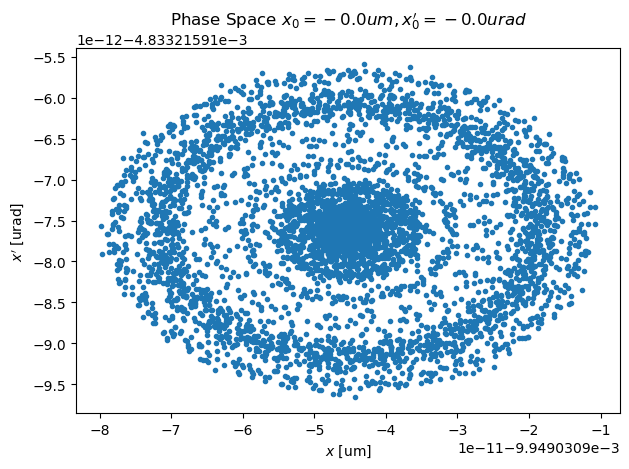

In [26]:
plt.figure()

label = f"$x_0={coord_ini[0]*1e6:.1f}um, x_0'={coord_ini[1]*1e6:.1f}urad$"
plt.plot(coord_fin[0, :]*1e6, coord_fin[1, :]*1e6, marker='.', ls='')
plt.xlabel('$x$ [um]')
plt.ylabel(r"$x'$ [urad]")
plt.title('Phase Space ' + label)
plt.tight_layout()
plt.show()

#### Tracking a bunch of particles

In [190]:
# 4D first then switch to 6D
model.cavity_on = True
model.radiation_on = True

In [186]:
emit1 = eqparam.emit1
emit2 = abs(eqparam.emit2)
espread = eqparam.espread0
bunlen = eqparam.bunlen
npart = 200

bunch = pyaccel.tracking.generate_bunch(
    emit1=emit1, emit2=emit2, sigmae=espread, sigmas=bunlen, optics=twiss[0], n_part=npart, cutoff=3)
bunch.shape

(6, 200)

In [187]:
print("emit1:", emit1, "\nemit2:", emit2, "\nespread:", espread, "\nbunlen:", bunlen)

emit1: 2.492615159581898e-10 
emit2: 1.6065709142375099e-37 
espread: 0.0008511126764794506 
bunlen: 0.00243722760788632


In [191]:
nturns = 500
bunch_tbt, *_ = pyaccel.tracking.ring_pass(model, bunch, nr_turns=nturns, turn_by_turn=True, parallel=True)
bunch_tbt.shape

(6, 200, 501)

In [192]:
plt.figure(figsize=(12, 8))

for part in range(15):
    label = f"$x_0={bunch_tbt[0, part, 0]*1e6:+04.0f}um, x_0'={bunch_tbt[1, part, 0]*1e6:+04.0f}urad$"
    plt.plot(bunch_tbt[0, part, :]*1e6, bunch_tbt[1, part, :]*1e6, marker='.', ls='', label=label)

plt.xlabel('$x$ [um]')
plt.ylabel(r"$x'$ [urad]")
plt.title('Phase Space ')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [193]:
bunch[0] += 5e-3
nturns = 100
bunch_tbt2, *_ = pyaccel.tracking.ring_pass(model, bunch, nr_turns=nturns, turn_by_turn=True, parallel=True)
bunch_tbt2.shape

(6, 200, 101)

In [178]:
bunch.shape

(6, 200)

In [179]:
%matplotlib qt5

In [194]:
plt.figure(figsize=(8, 8))
spos = pyaccel.lattice.find_spos(model)

nt = bunch_tbt2.shape[2]-1
cmap = plt.cm.jet(np.linspace(0, 1, nt+1))
plt.xlim([-7e3, 6e3])
plt.ylim([-400, 400])
plt.xlabel('$x$ [um]')
plt.ylabel(r"$x'$ [urad]")
plt.title('Phase Space ')
plt.tight_layout()
for i, cor in enumerate(cmap):
    plt.plot(bunch_tbt2[0, :, i]*1e6, bunch_tbt2[1, :, i]*1e6, marker='.', ls='', color=cor)
    plt.pause(0.5)
plt.show()

In [181]:
plt.figure(figsize=(8, 8))
for i in range(npart):
    plt.plot(bunch_tbt2[0, i, :]*1e6, color='C0', alpha=0.01)

plt.plot(np.mean(bunch_tbt2[0, :, :], axis=0)*1e6, lw=2, color='tab:red', label='Centroid')
plt.xlabel('turn index')
plt.ylabel(r"$x$ [um]")
plt.legend()
plt.tight_layout()
plt.show()

### Lifetime

In [182]:
model = pymodels.si.create_accelerator()
model = pymodels.si.fitted_models.vertical_dispersion_and_coupling(model)
cav = pyaccel.lattice.find_indices(model, 'fam_name', 'SRFCav')[0]
model[cav].voltage = 1.5e6
model.cavity_on=True
model.radiation_on=True
model.vchamber_on=True

In [183]:
ltime = pyaccel.lifetime.Lifetime(model)
# spos = twiss.spos
spos = pyaccel.lattice.find_spos(model, indices='closed')

RuntimeError: Edwards and Teng decomposition is restricted to symplectic 4D motion. Please turn off `cavity_on` and `radiation_on` flags.

In [ ]:
ltime.curr_per_bunch = 100/864
# ltime.avg_pressure = 2e-9

In [ ]:
ltime.lifetime_touschek/3600, float(ltime.lifetime_total/3600)

In [ ]:
enaccn, enaccp = pyaccel.optics.calc_touschek_energy_acceptance(model)
enaccn = np.maximum(enaccn, -ltime.equi_params.rf_acceptance)
enaccp = np.minimum(enaccp, ltime.equi_params.rf_acceptance)
ltime.accepen = (enaccn, enaccp)

Lifetime 

In [ ]:
plt.figure()
plt.plot(spos, enaccn*100)
plt.plot(spos, enaccp*100)
plt.xlabel('s [m]')
plt.ylabel(r'Touschek Energy Acceptance [%]')
plt.title('Energy Acceptance')
plt.xlim([0, model.length/20])
pyaccel.graphics.draw_lattice(model, offset=0, height=1, gca=True)
plt.tight_layout()
plt.show()

In [ ]:
ltime.lifetime_touschek/3600, float(ltime.lifetime_total/3600)